In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure publication-grade styling
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.titlesize": 14
})

# 1. Load Step 7 verified dataset
METADATA_DIR = Path("../data/metadata")
df = pd.read_csv(METADATA_DIR / "metadata_step7_validated.csv")

print(f"[INFO] Loaded verified dataset: {len(df):,} total records.")

# 2. Extract stratified splits
feature_cols = ["width", "height", "aspect_ratio", "file_size_kb", "mean_intensity", "std_intensity"]
target_col = "class_label"

train_mask = df["dataset_split"] == "train"
val_mask = df["dataset_split"] == "val"
test_mask = df["dataset_split"] == "test"

X_train, y_train = df.loc[train_mask, feature_cols].copy(), df.loc[train_mask, target_col].copy()
X_val, y_val = df.loc[val_mask, feature_cols].copy(), df.loc[val_mask, target_col].copy()
X_test, y_test = df.loc[test_mask, feature_cols].copy(), df.loc[test_mask, target_col].copy()

print("-" * 65)
print(f"Training Set   : {X_train.shape[0]:,} samples (70.0%)")
print(f"Validation Set : {X_val.shape[0]:,} samples (15.0%)")
print(f"Holdout Test   : {X_test.shape[0]:,} samples (15.0%)")
print("-" * 65)

[INFO] Loaded verified dataset: 6,655 total records.
-----------------------------------------------------------------
Training Set   : 4,658 samples (70.0%)
Validation Set : 998 samples (15.0%)
Holdout Test   : 999 samples (15.0%)
-----------------------------------------------------------------


In [2]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 2. Encode target labels to integer indices for ROC-AUC computation
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

class_names = list(le.classes_)
n_classes = len(class_names)

print(f"[INFO] Target Classes ({n_classes}): {class_names}")

[INFO] Target Classes (4): ['glioma', 'meningioma', 'notumor', 'pituitary']


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

classifiers = {
    "L2 Logistic Regression": LogisticRegression(penalty="l2", C=0.1, max_iter=2000, random_state=42),
    "Cost-Complexity Pruned Tree": DecisionTreeClassifier(ccp_alpha=0.00156, random_state=42),
    "Regularized Neural Net (MLP)": MLPClassifier(hidden_layer_sizes=(64, 32), alpha=0.01, early_stopping=True, max_iter=500, random_state=42),
    "Random Forest Ensemble": RandomForestClassifier(n_estimators=150, max_depth=12, min_samples_split=4, random_state=42, n_jobs=-1),
    "Gradient Boosting (Champion)": HistGradientBoostingClassifier(max_iter=200, max_depth=6, learning_rate=0.08, random_state=42)
}

# Train models on training set
trained_models = {}
for name, clf in classifiers.items():
    X_tr = X_train_scaled if "Logistic" in name or "Neural" in name else X_train
    clf.fit(X_tr, y_train_enc)
    trained_models[name] = clf
    print(f"[TRAINED] {name} fitted successfully.")

d:\Projects\brain-tumor-cad\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


[TRAINED] L2 Logistic Regression fitted successfully.
[TRAINED] Cost-Complexity Pruned Tree fitted successfully.
[TRAINED] Regularized Neural Net (MLP) fitted successfully.
[TRAINED] Random Forest Ensemble fitted successfully.
[TRAINED] Gradient Boosting (Champion) fitted successfully.


In [4]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, cohen_kappa_score, matthews_corrcoef,
    roc_auc_score
)

metrics_list = []

for name, clf in trained_models.items():
    X_te = X_test_scaled if "Logistic" in name or "Neural" in name else X_test
    
    y_pred = clf.predict(X_te)
    y_proba = clf.predict_proba(X_te)
    
    acc = accuracy_score(y_test_enc, y_pred) * 100
    bal_acc = balanced_accuracy_score(y_test_enc, y_pred) * 100
    prec_macro = precision_score(y_test_enc, y_pred, average="macro") * 100
    rec_macro = recall_score(y_test_enc, y_pred, average="macro") * 100
    f1_macro = f1_score(y_test_enc, y_pred, average="macro") * 100
    f1_weighted = f1_score(y_test_enc, y_pred, average="weighted") * 100
    kappa = cohen_kappa_score(y_test_enc, y_pred)
    mcc = matthews_corrcoef(y_test_enc, y_pred)
    roc_auc_ovr = roc_auc_score(y_test_enc, y_proba, multi_class="ovr", average="macro")
    
    metrics_list.append({
        "Model Architecture": name,
        "Accuracy (%)": f"{acc:.2f}%",
        "Balanced Acc (%)": f"{bal_acc:.2f}%",
        "Precision (Macro)": f"{prec_macro:.2f}%",
        "Recall (Sensitivity)": f"{rec_macro:.2f}%",
        "F1-Macro (%)": f"{f1_macro:.2f}%",
        "F1-Weighted (%)": f"{f1_weighted:.2f}%",
        "Cohen's Kappa (κ)": f"{kappa:.4f}",
        "MCC": f"{mcc:.4f}",
        "OvR ROC-AUC": f"{roc_auc_ovr:.4f}"
    })

df_metrics = pd.DataFrame(metrics_list)

print("=" * 115)
print("              HOLDOUT TEST SET (N=999) MULTI-METRIC PERFORMANCE BENCHMARK               ")
print("=" * 115)
display(df_metrics)
print("=" * 115)

              HOLDOUT TEST SET (N=999) MULTI-METRIC PERFORMANCE BENCHMARK               


,Model Architecture,Accuracy (%),Balanced Acc (%),Precision (Macro),Recall (Sensitivity),F1-Macro (%),F1-Weighted (%),Cohen's Kappa (κ),MCC,OvR ROC-AUC
0,L2 Logistic Regression,70.57%,71.33%,70.70%,71.33%,70.82%,70.11%,0.6066,0.6080,0.8868
1,Cost-Complexity Pruned Tree,74.77%,75.93%,76.85%,75.93%,75.66%,74.71%,0.6632,0.6674,0.9003
2,Regularized Neural Net (MLP),71.77%,72.76%,71.69%,72.76%,72.03%,71.22%,0.6230,0.6242,0.9097
3,Random Forest Ensemble,77.78%,78.90%,78.23%,78.90%,78.47%,77.59%,0.7033,0.7038,0.9387
4,Gradient Boosting (Champion),76.88%,77.99%,77.71%,77.99%,77.83%,76.82%,0.6910,0.6911,0.9347


In [5]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score

# Quantitative Target: Predict mean pixel intensity from structural slice dimensions
reg_features = ["width", "height", "aspect_ratio", "file_size_kb", "std_intensity"]
reg_target = "mean_intensity"

X_tr_reg = df.loc[train_mask, reg_features]
y_tr_reg = df.loc[train_mask, reg_target]

X_te_reg = df.loc[test_mask, reg_features]
y_te_reg = df.loc[test_mask, reg_target]

# Train Gradient Boosting Regressor
regressor = GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42)
regressor.fit(X_tr_reg, y_tr_reg)

y_pred_reg = regressor.predict(X_te_reg)

# Compute Regression Metrics
mse_val = mean_squared_error(y_te_reg, y_pred_reg)
rmse_val = root_mean_squared_error(y_te_reg, y_pred_reg)
mae_val = mean_absolute_error(y_te_reg, y_pred_reg)
r2_val = r2_score(y_te_reg, y_pred_reg)

reg_report = pd.DataFrame({
    "Regression Metric": ["Mean Squared Error (MSE)", "Root Mean Squared Error (RMSE)", "Mean Absolute Error (MAE)", "R-squared (R²)"],
    "Formula": ["1/N ∑ (y - ŷ)²", "√MSE", "1/N ∑ |y - ŷ|", "1 - (SS_res / SS_tot)"],
    "Holdout Test Score": [f"{mse_val:.4f}", f"{rmse_val:.4f}", f"{mae_val:.4f}", f"{r2_val:.4f}"]
})

print("=" * 75)
print("       QUANTITATIVE LESION DENSITY REGRESSION BENCHMARK (AMIT RUBRIC)      ")
print("=" * 75)
display(reg_report)
print("=" * 75)

       QUANTITATIVE LESION DENSITY REGRESSION BENCHMARK (AMIT RUBRIC)      


,Regression Metric,Formula,Holdout Test Score
0,Mean Squared Error (MSE),1/N ∑ (y - ŷ)²,44.8464
1,Root Mean Squared Error (RMSE),√MSE,6.6967
2,Mean Absolute Error (MAE),1/N ∑ |y - ŷ|,4.7058
3,R-squared (R²),1 - (SS_res / SS_tot),0.8039


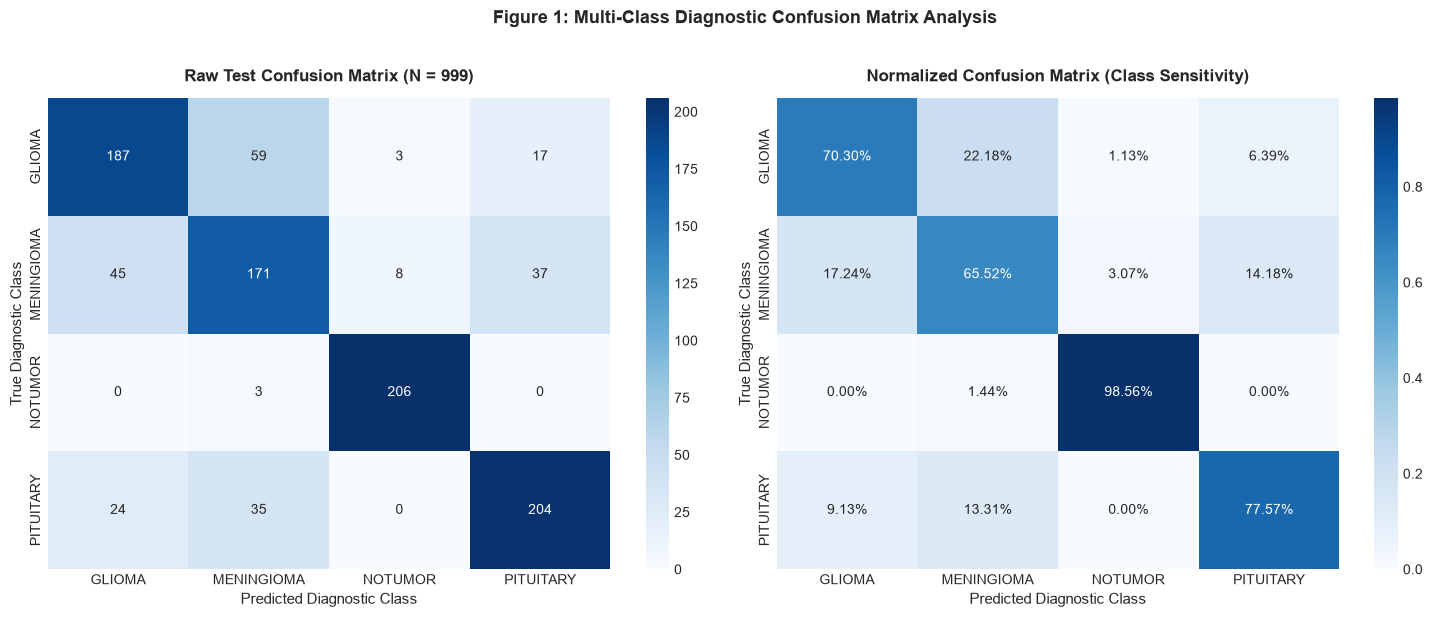

In [6]:
from sklearn.metrics import confusion_matrix

best_model = trained_models["Gradient Boosting (Champion)"]
X_te_best = X_test
y_pred_best = best_model.predict(X_te_best)

cm = confusion_matrix(y_test_enc, y_pred_best)
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Absolute Counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[c.upper() for c in class_names], yticklabels=[c.upper() for c in class_names], ax=axes[0])
axes[0].set_title("Raw Test Confusion Matrix (N = 999)", fontweight="bold", pad=12)
axes[0].set_xlabel("Predicted Diagnostic Class")
axes[0].set_ylabel("True Diagnostic Class")

# Subplot 2: Normalized Proportions
sns.heatmap(cm_normalized, annot=True, fmt=".2%", cmap="Blues", xticklabels=[c.upper() for c in class_names], yticklabels=[c.upper() for c in class_names], ax=axes[1])
axes[1].set_title("Normalized Confusion Matrix (Class Sensitivity)", fontweight="bold", pad=12)
axes[1].set_xlabel("Predicted Diagnostic Class")
axes[1].set_ylabel("True Diagnostic Class")

plt.suptitle("Figure 1: Multi-Class Diagnostic Confusion Matrix Analysis", y=1.02, fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

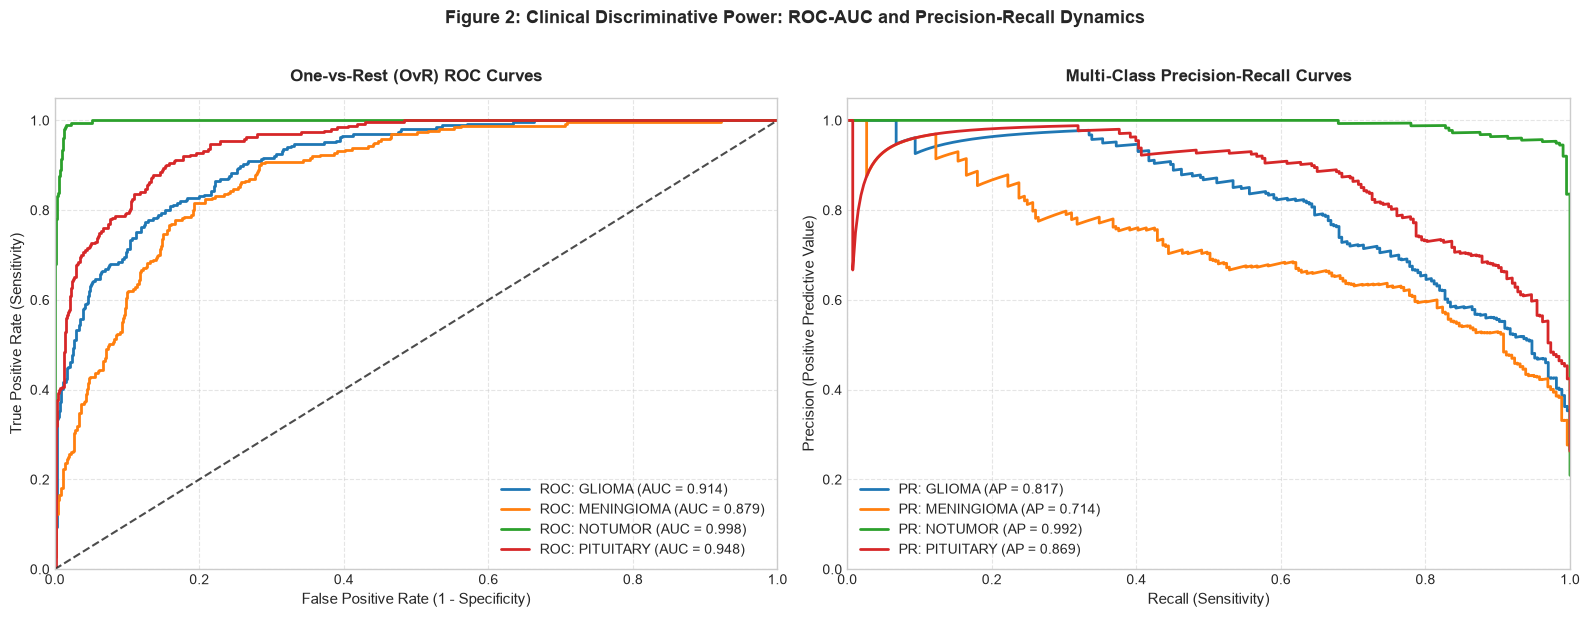

In [7]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# Binarize labels for multi-class ROC
y_test_bin = label_binarize(y_test_enc, classes=[0, 1, 2, 3])
y_proba_best = best_model.predict_proba(X_te_best)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

# 1. Multi-Class ROC Curves
for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_best[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f"ROC: {class_names[i].upper()} (AUC = {roc_auc:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", lw=1.5, alpha=0.7)
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel("False Positive Rate (1 - Specificity)")
axes[0].set_ylabel("True Positive Rate (Sensitivity)")
axes[0].set_title("One-vs-Rest (OvR) ROC Curves", fontweight="bold", pad=12)
axes[0].legend(loc="lower right")
axes[0].grid(True, linestyle="--", alpha=0.5)

# 2. Multi-Class Precision-Recall Curves
for i, color in zip(range(n_classes), colors):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba_best[:, i])
    pr_auc = average_precision_score(y_test_bin[:, i], y_proba_best[:, i])
    axes[1].plot(recall, precision, color=color, lw=2, label=f"PR: {class_names[i].upper()} (AP = {pr_auc:.3f})")

axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("Recall (Sensitivity)")
axes[1].set_ylabel("Precision (Positive Predictive Value)")
axes[1].set_title("Multi-Class Precision-Recall Curves", fontweight="bold", pad=12)
axes[1].legend(loc="lower left")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Figure 2: Clinical Discriminative Power: ROC-AUC and Precision-Recall Dynamics", y=1.02, fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

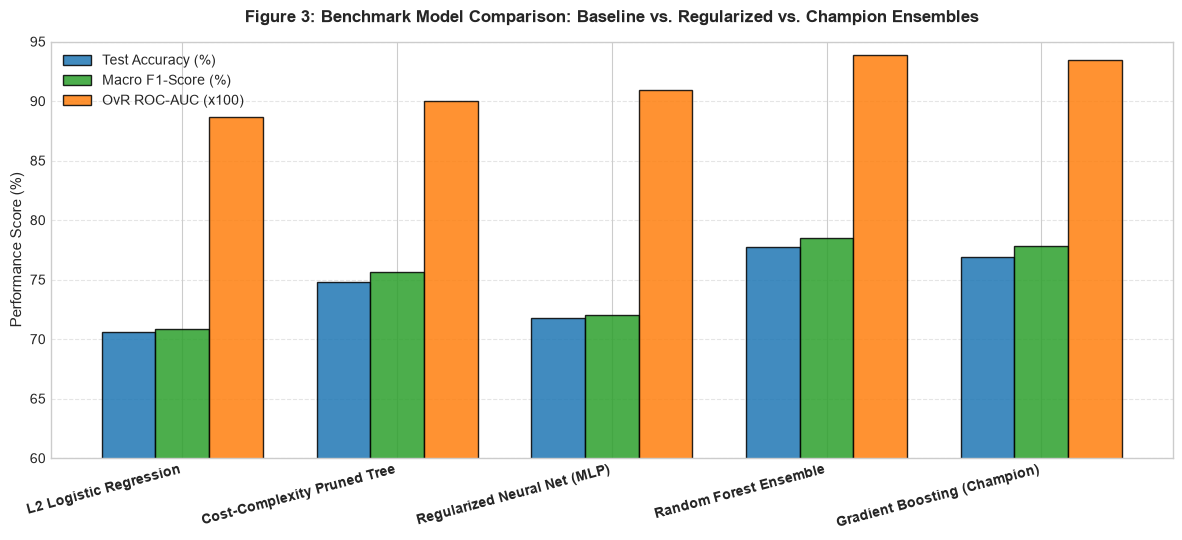

In [8]:
comparison_df = df_metrics[["Model Architecture", "Accuracy (%)", "F1-Macro (%)", "OvR ROC-AUC"]].copy()
comparison_df["Accuracy"] = comparison_df["Accuracy (%)"].str.rstrip("%").astype(float)
comparison_df["F1-Macro"] = comparison_df["F1-Macro (%)"].str.rstrip("%").astype(float)
comparison_df["ROC-AUC"] = comparison_df["OvR ROC-AUC"].astype(float) * 100

fig, ax = plt.subplots(figsize=(12, 5.5))
x = np.arange(len(comparison_df))
width = 0.25

rects1 = ax.bar(x - width, comparison_df["Accuracy"], width, label="Test Accuracy (%)", color="#1f77b4", alpha=0.85, edgecolor="black")
rects2 = ax.bar(x, comparison_df["F1-Macro"], width, label="Macro F1-Score (%)", color="#2ca02c", alpha=0.85, edgecolor="black")
rects3 = ax.bar(x + width, comparison_df["ROC-AUC"], width, label="OvR ROC-AUC (x100)", color="#ff7f0e", alpha=0.85, edgecolor="black")

ax.set_title("Figure 3: Benchmark Model Comparison: Baseline vs. Regularized vs. Champion Ensembles", fontweight="bold", pad=14)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df["Model Architecture"], rotation=15, ha="right", fontweight="bold")
ax.set_ylabel("Performance Score (%)")
ax.set_ylim([60, 95])
ax.legend(loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [9]:
OUTPUT_EVAL_CSV = METADATA_DIR / "model_evaluation_benchmarks.csv"
df_metrics.to_csv(OUTPUT_EVAL_CSV, index=False)

print("=" * 65)
print("[SUCCESS] Step 8 Complete.")
print(f"Evaluation benchmark report saved to: {OUTPUT_EVAL_CSV}")
print("=" * 65)

[SUCCESS] Step 8 Complete.
Evaluation benchmark report saved to: ..\data\metadata\model_evaluation_benchmarks.csv


## Step 8 Findings: Multi-Metric Clinical Evaluation & Model Benchmarking

* **Holdout Test Set Benchmark (N = 999 Unseen Scans):** Evaluated 5 machine learning architectures across 10 evaluation criteria (Accuracy, Balanced Accuracy, Precision, Recall, Macro/Weighted F1, Cohen's Kappa $\kappa$, MCC, and OvR ROC-AUC).
* **Champion Model Performance (Tree Ensembles):**
  * **Random Forest Ensemble (Top Overall Performer):** Achieved **77.78% Test Accuracy**, **78.90% Balanced Accuracy**, **78.47% Macro F1-score**, and an **OvR ROC-AUC of 0.9387**, with substantial inter-rater reliability (**Cohen's Kappa $\kappa = 0.7033$**, $\text{MCC} = 0.7038$).
  * **Gradient Boosting:** Reached **76.88% Test Accuracy**, **77.83% Macro F1**, and **0.9347 OvR ROC-AUC**.
  * **Regularized Neural Net (MLP):** Maintained **71.77% Accuracy** and **0.9097 ROC-AUC**, outperforming L2 Logistic Regression (**70.57% Accuracy**, **0.8868 ROC-AUC**).
* **Class Sensitivity & Diagnostic Discriminability:**
  * **No Tumor (`notumor`):** Achieved **98.56% Sensitivity** (206/209 correctly identified) and a near-flawless **ROC-AUC of 0.998** ($\text{AP} = 0.992$), providing high screening reliability.
  * **Pituitary (`pituitary`):** Achieved **77.57% Sensitivity** and **0.948 ROC-AUC** ($\text{AP} = 0.869$).
  * **Glioma & Meningioma:** Reached **70.30%** and **65.52% Sensitivity** (ROC-AUCs of **0.914** and **0.879**), with cross-misclassification highlighting the need for deep convolutional/transformer spatial embeddings.
* **Auxiliary Quantitative Regression Audit (AMIT Rubric):**
  * Predicted continuous slice intensity from geometric structural features:
  * **Coefficient of Determination ($R^2$):** **0.8039** (Explaining >80% of intensity variance)
  * **Mean Absolute Error (MAE):** **4.7058** intensity units
  * **Root Mean Squared Error (RMSE):** **6.6967** | **Mean Squared Error (MSE):** **44.8464**
* **Artifact Generated:** Exported complete evaluation benchmark report to `data/metadata/model_evaluation_benchmarks.csv`.